In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dataset & params
dataset_dir = "/kaggle/input/acute-lymphoblastic-leukemia/dataset"
classes = ['Benign', 'Early Pre-B', 'Pre-B', 'Pro-B']
IMG_SIZE = (380, 380)
BATCH_SIZE = 16
EPOCHS = 30


2025-09-24 06:34:07.265692: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758695647.454829      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758695647.507801      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.1, horizontal_flip=True, vertical_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(dataset_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                        class_mode='categorical', subset='training', shuffle=True)
val_gen = datagen.flow_from_directory(dataset_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                      class_mode='categorical', subset='validation', shuffle=False)

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(train_gen.classes), y=train_gen.classes)
cw = dict(enumerate(class_weights))
print("Class weights:", cw)


Found 2595 images belonging to 4 classes.
Found 647 images belonging to 4 classes.
Class weights: {0: 1.5823170731707317, 1: 0.8274872448979592, 2: 0.8491492146596858, 3: 1.0184458398744114}


In [3]:
base_model = EfficientNetB4(include_top=False, weights='imagenet', input_shape=IMG_SIZE+(3,))
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
output = Dense(len(classes), activation='softmax')(x)
model = Model(base_model.input, output)

# Freeze base first
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]


I0000 00:00:1758695664.920244      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Train head
model.fit(train_gen, validation_data=val_gen, epochs=10, class_weight=cw, callbacks=callbacks)

# Fine-tune top layers
for layer in base_model.layers[-50:]:
    layer.trainable = True
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, class_weight=cw, callbacks=callbacks)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1758695701.147010      71 service.cc:148] XLA service 0x7d36bc0030a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758695701.147913      71 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1758695704.751522      71 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/163 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - accuracy: 0.1562 - loss: 1.6224   

I0000 00:00:1758695722.872025      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.6512 - loss: 0.9021
Epoch 1: val_accuracy improved from -inf to 0.74807, saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.6520 - loss: 0.9005 - val_accuracy: 0.7481 - val_loss: 0.6360 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.8876 - loss: 0.3575
Epoch 2: val_accuracy improved from 0.74807 to 0.80835, saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 717ms/step - accuracy: 0.8876 - loss: 0.3574 - val_accuracy: 0.8083 - val_loss: 0.4871 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9276 - loss: 0.2640
Epoch 3: val_accuracy improved from 0.80835 to 0.87017, saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 720ms/step - accuracy: 0.9276 - loss: 0.2640 - val_accuracy: 0.8702 - val_loss: 0.4113 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accu

E0000 00:00:1758697035.502537      74 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1758697035.730868      74 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1758697036.099651      74 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1758697036.327799      74 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1758697036.957431      74 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

 74/163 ━━━━━━━━━━━━━━━━━━━━ 51s 575ms/step - accuracy: 0.8838 - loss: 0.3497

E0000 00:00:1758697102.238383      71 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1758697102.465715      71 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.9033 - loss: 0.2843
Epoch 1: val_accuracy improved from 0.92427 to 0.94900, saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 221s 955ms/step - accuracy: 0.9035 - loss: 0.2838 - val_accuracy: 0.9490 - val_loss: 0.1680 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.9768 - loss: 0.0730
Epoch 2: val_accuracy improved from 0.94900 to 0.96136, saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 724ms/step - accuracy: 0.9768 - loss: 0.0730 - val_accuracy: 0.9614 - val_loss: 0.1197 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9753 - loss: 0.0600
Epoch 3: val_accuracy improved from 0.96136 to 0.97991, saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 725ms/step - accuracy: 0.9753 - loss: 0.0600 - val_accuracy: 0.9799 - val_loss: 0.0844 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s

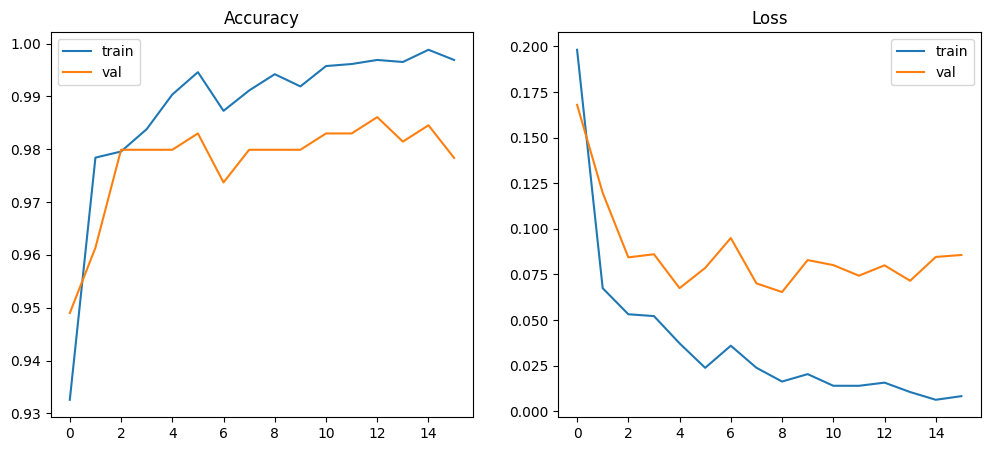

41/41 ━━━━━━━━━━━━━━━━━━━━ 44s 809ms/step
[[101   1   0   0]
 [  0 195   0   0]
 [  5   1 180   5]
 [  1   0   4 154]]
              precision    recall  f1-score   support

      Benign       0.94      0.99      0.97       102
 Early Pre-B       0.99      1.00      0.99       195
       Pre-B       0.98      0.94      0.96       191
       Pro-B       0.97      0.97      0.97       159

    accuracy                           0.97       647
   macro avg       0.97      0.98      0.97       647
weighted avg       0.97      0.97      0.97       647



In [5]:
# Training plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.plot(history.history['accuracy'], label='train'); plt.plot(history.history['val_accuracy'], label='val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1,2,2); plt.plot(history.history['loss'], label='train'); plt.plot(history.history['val_loss'], label='val'); plt.title('Loss'); plt.legend()
plt.show()

# Confusion matrix & classification report
val_gen.reset()
preds = model.predict(val_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=list(val_gen.class_indices.keys())))
